DATA LOADING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error
import os
from sklearn.preprocessing import StandardScaler
import seaborn as sns


In [2]:
# CARICAMENTO DEL DATASET
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

clinical_df = pd.read_csv("PDAC_data/clinical_data.csv",index_col=0)
circRNA_df = pd.read_csv("PDAC_data/circRNA.csv",index_col=0)
miRNA_df = pd.read_csv("PDAC_data/miRNA.csv",index_col=0)
mRNA_df = pd.read_csv("PDAC_data/mRNA.csv",index_col=0)
phosphoproteome_df = pd.read_csv("PDAC_data/phosphoproteome_gene.csv",index_col=0)
proteome_df = pd.read_csv("PDAC_data/proteome_gene.csv",index_col=0)
SCNA_df = pd.read_csv("PDAC_data/SCNA_gene.csv",index_col=0)

print("clinical:", clinical_df.shape)
print("circRNA:", circRNA_df.shape)
print("miRNA:", miRNA_df.shape)
print("mRNA:", mRNA_df.shape)
print("phosphoproteome:", phosphoproteome_df.shape)
print("proteome:", proteome_df.shape)
print("SCNA:", SCNA_df.shape)

clinical: (140, 24)
circRNA: (3979, 137)
miRNA: (2416, 137)
mRNA: (28057, 137)
phosphoproteome: (8004, 137)
proteome: (11662, 137)
SCNA: (19906, 137)


DATA PREPROCESSING

In [3]:
# TRASPOSIZIONE DEI DATASET

circRNA_df = circRNA_df.T
miRNA_df = miRNA_df.T
mRNA_df = mRNA_df.T
phosphoproteome_df = phosphoproteome_df.T
proteome_df = proteome_df.T
SCNA_df = SCNA_df.T

print("Dopo la trasposizione:")
print("clinical:", clinical_df.shape)
print("circRNA:", circRNA_df.shape)
print("miRNA:", miRNA_df.shape)
print("mRNA:", mRNA_df.shape)
print("phosphoproteome:", phosphoproteome_df.shape)
print("proteome:", proteome_df.shape)
print("SCNA:", SCNA_df.shape)

views = {
    "circRNA": circRNA_df,
    "miRNA": miRNA_df,
    "mRNA": mRNA_df,
    "phosphoproteome": phosphoproteome_df,
    "proteome": proteome_df,
    "SCNA": SCNA_df
}

Dopo la trasposizione:
clinical: (140, 24)
circRNA: (137, 3979)
miRNA: (137, 2416)
mRNA: (137, 28057)
phosphoproteome: (137, 8004)
proteome: (137, 11662)
SCNA: (137, 19906)


In [4]:
# ALLINEAMENTO DELLE VISTE SUI PAZIENTI COMUNI

def align_views(clinical_df, views):
    summary = {}

    # Calcola summary per ogni vista
    for name, df in views.items():
        # Pazienti in comune con clinical_df
        in_common = clinical_df.index[clinical_df.index.isin(df.index)]
        not_in_common = clinical_df.index[~clinical_df.index.isin(df.index)]

        summary[name] = {
            "in_common": len(in_common),
            "not_in_common": len(not_in_common),
            "not_in_common_ids": list(not_in_common)
        }

        print(f"{name}:")
        print(f"Pazienti in comune con clinical_data: {len(in_common)}")
        print(f"Pazienti non in comune con clinical_data: {len(not_in_common)}\n")

    # Trova tutti i pazienti mancanti in almeno una vista
    patients_not_in_all_views = set()
    for info in summary.values():
        patients_not_in_all_views.update(info["not_in_common_ids"])

    print("Pazienti non presenti in almeno una vista:")
    for patient in patients_not_in_all_views:
        missing_in = [name for name, info in summary.items()
                    if patient in info["not_in_common_ids"]]
        print(f"  Paziente {patient} mancante in: {missing_in}")

    # Rimuove questi pazienti da tutte le viste
    aligned_views = {}
    for name, df in views.items():
        aligned_views[name] = df.drop(index=patients_not_in_all_views, errors='ignore')

    # Rimuove questi pazienti anche dal clinical_df
    aligned_clinical_df = clinical_df.drop(index=patients_not_in_all_views, errors='ignore')

    return aligned_views, aligned_clinical_df


aligned_views, clinical_df = align_views(clinical_df, views)
print("clinical:", clinical_df.shape)
print("circRNA:", aligned_views["circRNA"].shape)
print("miRNA:", aligned_views["miRNA"].shape)
print("mRNA:", aligned_views["mRNA"].shape)
print("phosphoproteome:", aligned_views["phosphoproteome"].shape)
print("proteome:", aligned_views["proteome"].shape)
print("SCNA:", aligned_views["SCNA"].shape)

circRNA:
Pazienti in comune con clinical_data: 137
Pazienti non in comune con clinical_data: 3

miRNA:
Pazienti in comune con clinical_data: 137
Pazienti non in comune con clinical_data: 3

mRNA:
Pazienti in comune con clinical_data: 137
Pazienti non in comune con clinical_data: 3

phosphoproteome:
Pazienti in comune con clinical_data: 137
Pazienti non in comune con clinical_data: 3

proteome:
Pazienti in comune con clinical_data: 137
Pazienti non in comune con clinical_data: 3

SCNA:
Pazienti in comune con clinical_data: 137
Pazienti non in comune con clinical_data: 3

Pazienti non presenti in almeno una vista:
  Paziente C3L-02890 mancante in: ['circRNA', 'miRNA', 'mRNA', 'phosphoproteome', 'proteome', 'SCNA']
  Paziente C3L-02115 mancante in: ['circRNA', 'miRNA', 'mRNA', 'phosphoproteome', 'proteome', 'SCNA']
  Paziente C3N-01997 mancante in: ['circRNA', 'miRNA', 'mRNA', 'phosphoproteome', 'proteome', 'SCNA']
clinical: (137, 24)
circRNA: (137, 3979)
miRNA: (137, 2416)
mRNA: (137, 28

In [5]:

# DataFrame clinico
print("=== Clinical Data ===")
#print(clinical_df.head(10))
print(clinical_df.columns.tolist())
'''
# DataFrame delle viste omiche
for view_name, df in aligned_views.items():
    print(f"\n=== Vista: {view_name} ===")
    #print(df.head(10))
    print(df.columns.tolist())
'''

=== Clinical Data ===
['histology_diagnosis', 'age', 'sex', 'race', 'participant_country', 'tumor_site', 'tumor_size_cm', 'tumor_necrosis', 'lymph_vascular_invasion', 'perineural_invasion', 'pathologic_staging_regiol_lymph_nodes_pn', 'pathologic_staging_primary_tumor_pt', 'pathologic_staging_distant_metastasis_pm', 'clinical_staging_distant_metastasis_cm', 'residual_tumor', 'tumor_stage_pathological', 'additiol_pathologic_findings', 'bmi', 'alcohol_consumption', 'tobacco_smoking_history', 'follow_up_days', 'vital_status', 'is_this_patient_lost_to_follow_up', 'cause_of_death']


'\n# DataFrame delle viste omiche\nfor view_name, df in aligned_views.items():\n    print(f"\n=== Vista: {view_name} ===")\n    #print(df.head(10))\n    print(df.columns.tolist())\n'

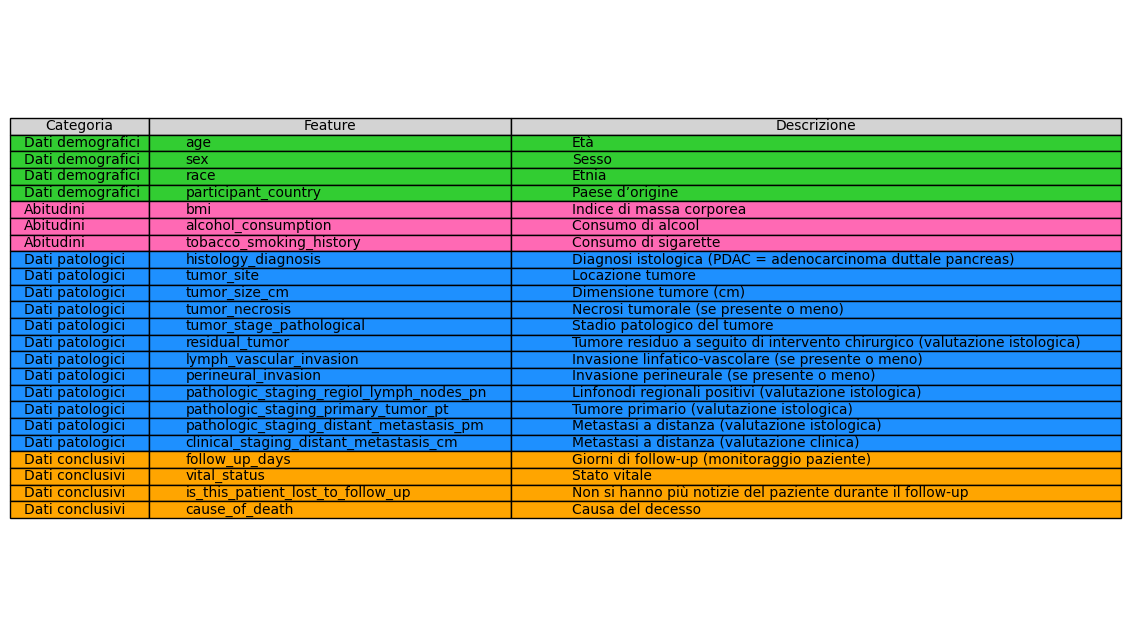

In [6]:
# --- Dati della tabella ---
data = [
    ["Dati demografici", "age", "Età"],
    ["Dati demografici", "sex", "Sesso"],
    ["Dati demografici", "race", "Etnia"],
    ["Dati demografici", "participant_country", "Paese d’origine"],
    ["Abitudini", "bmi", "Indice di massa corporea"],
    ["Abitudini", "alcohol_consumption", "Consumo di alcool"],
    ["Abitudini", "tobacco_smoking_history", "Consumo di sigarette"],
    ["Dati patologici", "histology_diagnosis", "Diagnosi istologica (PDAC = adenocarcinoma duttale pancreas)"],
    ["Dati patologici", "tumor_site", "Locazione tumore"],
    ["Dati patologici", "tumor_size_cm", "Dimensione tumore (cm)"],
    ["Dati patologici", "tumor_necrosis", "Necrosi tumorale (se presente o meno)"],
    ["Dati patologici", "tumor_stage_pathological", "Stadio patologico del tumore"],
    ["Dati patologici", "residual_tumor", "Tumore residuo a seguito di intervento chirurgico (valutazione istologica)"],
    ["Dati patologici", "lymph_vascular_invasion", "Invasione linfatico-vascolare (se presente o meno)"],
    ["Dati patologici", "perineural_invasion", "Invasione perineurale (se presente o meno)"],
    ["Dati patologici", "pathologic_staging_regiol_lymph_nodes_pn", "Linfonodi regionali positivi (valutazione istologica)"],
    ["Dati patologici", "pathologic_staging_primary_tumor_pt", "Tumore primario (valutazione istologica)"],
    ["Dati patologici", "pathologic_staging_distant_metastasis_pm", "Metastasi a distanza (valutazione istologica)"],
    ["Dati patologici", "clinical_staging_distant_metastasis_cm", "Metastasi a distanza (valutazione clinica)"],
    ["Dati conclusivi", "follow_up_days", "Giorni di follow-up (monitoraggio paziente)"],
    ["Dati conclusivi", "vital_status", "Stato vitale"],
    ["Dati conclusivi","is_this_patient_lost_to_follow_up", "Non si hanno più notizie del paziente durante il follow-up"],
    ["Dati conclusivi", "cause_of_death", "Causa del decesso"],
]

df = pd.DataFrame(data, columns=["Categoria", "Feature", "Descrizione"])

# --- Creazione immagine ---
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')  # nasconde assi

# Tabella
tbl = ax.table(cellText=df.values,
               colLabels=df.columns,
               cellLoc='left',
               colColours=["lightgrey"]*3,
               loc='center')

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.auto_set_column_width([0, 1, 2])

# --- Colorazione righe per categoria ---
colors = {
    "Dati demografici":  "#32CD32", 
    "Abitudini": "#FF69B4",        
    "Dati patologici": "#1E90FF",   
    "Dati conclusivi": "#FFA500"   
}

# Salta l'intestazione (riga 0)
for i, cat in enumerate(df['Categoria']):
    color = colors.get(cat, "white")
    for j in range(3):  # tre colonne
        tbl[(i+1, j)].set_facecolor(color)

plt.show()

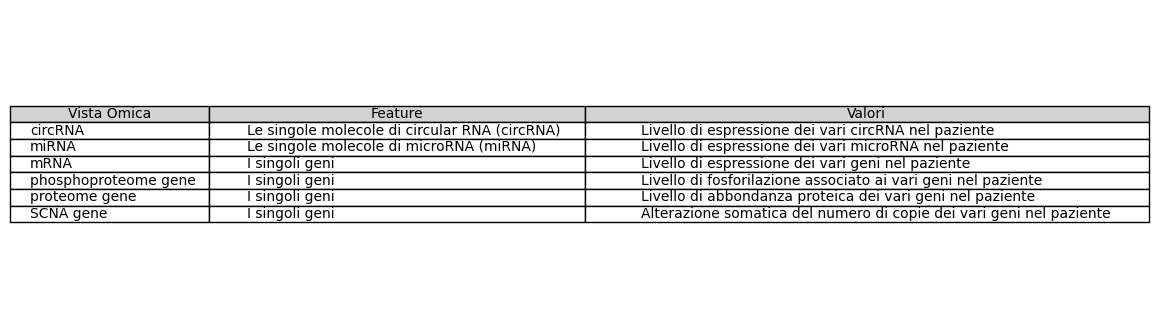

'\n\n# --- Tabella 1: Vista Omica - Descrizione ---\ndf_desc = df[["Vista Omica", "Descrizione"]]\n\nfig, ax = plt.subplots(figsize=(12, 3))\nax.axis(\'off\')\n\ntbl1 = ax.table(cellText=df_desc.values,\n                colLabels=df_desc.columns,\n                cellLoc=\'left\',\n                colColours=["lightgrey"] * 2,\n                loc=\'center\')\n\ntbl1.auto_set_font_size(False)\ntbl1.set_fontsize(10)\ntbl1.auto_set_column_width([0, 1])\n\nplt.show()\n\n# --- Tabella 2: Vista Omica - Feature ---\ndf_feat = df[["Vista Omica", "Feature"]]\n\nfig, ax = plt.subplots(figsize=(12, 3))\nax.axis(\'off\')\n\ntbl2 = ax.table(cellText=df_feat.values,\n                colLabels=df_feat.columns,\n                cellLoc=\'left\',\n                colColours=["lightgrey"] * 2,\n                loc=\'center\')\n\ntbl2.auto_set_font_size(False)\ntbl2.set_fontsize(10)\ntbl2.auto_set_column_width([0, 1])\n\nplt.show()\n\n# --- Tabella 3: Vista Omica - Valori ---\ndf_val = df[["Vista Omica"

In [7]:
# --- Dati base ---
data = [
    ["circRNA",
     "Le singole molecole di circular RNA (circRNA)",
     "Livello di espressione dei vari circRNA nel paziente",
     "Contiene i livelli di espressione (conteggi) dei circular RNA."],

    ["miRNA",
     "Le singole molecole di microRNA (miRNA)",
     "Livello di espressione dei vari microRNA nel paziente",
     "Contiene i livelli di espressione (conteggi) dei microRNA (miRNA)."],

    ["mRNA",
     "I singoli geni",
     "Livello di espressione dei vari geni nel paziente",
     "Contiene i livelli di espressione (conteggi) degli mRNA, che rappresentano i geni."],

    ["phosphoproteome gene",
     "I singoli geni",
     "Livello di fosforilazione associato ai vari geni nel paziente",
     "Contiene dati di fosfoproteomica, aggregati a livello genico."],

    ["proteome gene",
     "I singoli geni",
     "Livello di abbondanza proteica dei vari geni nel paziente",
     "Contiene dati di proteomica, aggregati a livello genico."],

    ["SCNA gene",
     "I singoli geni",
     "Alterazione somatica del numero di copie dei vari geni nel paziente",
     "Contiene dati sulle SCNA (Somatic Copy Number Alterations), indicando delezioni o amplificazioni dei geni nel tumore."]
]

df = pd.DataFrame(data, columns=["Vista Omica", "Feature", "Valori", "Descrizione"])

# Selezione colonne richieste
df_tabella = df[["Vista Omica", "Feature", "Valori"]]

# Creazione tabella
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

tbl = ax.table(
    cellText=df_tabella.values,
    colLabels=df_tabella.columns,
    cellLoc='left',
    colColours=["lightgrey"] * 3,
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.auto_set_column_width([0, 1, 2])

plt.show()

'''

# --- Tabella 1: Vista Omica - Descrizione ---
df_desc = df[["Vista Omica", "Descrizione"]]

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

tbl1 = ax.table(cellText=df_desc.values,
                colLabels=df_desc.columns,
                cellLoc='left',
                colColours=["lightgrey"] * 2,
                loc='center')

tbl1.auto_set_font_size(False)
tbl1.set_fontsize(10)
tbl1.auto_set_column_width([0, 1])

plt.show()

# --- Tabella 2: Vista Omica - Feature ---
df_feat = df[["Vista Omica", "Feature"]]

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

tbl2 = ax.table(cellText=df_feat.values,
                colLabels=df_feat.columns,
                cellLoc='left',
                colColours=["lightgrey"] * 2,
                loc='center')

tbl2.auto_set_font_size(False)
tbl2.set_fontsize(10)
tbl2.auto_set_column_width([0, 1])

plt.show()

# --- Tabella 3: Vista Omica - Valori ---
df_val = df[["Vista Omica", "Valori"]]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis('off')

tbl3 = ax.table(cellText=df_val.values,
                colLabels=df_val.columns,
                cellLoc='left',
                colColours=["lightgrey"] * 2,
                loc='center')

tbl3.auto_set_font_size(False)
tbl3.set_fontsize(10)
tbl3.auto_set_column_width([0, 1])

plt.show()
'''




In [8]:
# VISUALIZZAZIONE DEI CONTEGGI DEI VALORI PRIMA DELL'ENCODING

for col in clinical_df.columns:
    print(f"\n=== value_counts per la colonna '{col}': ===")
    print(clinical_df[col].value_counts(dropna=False))


=== value_counts per la colonna 'histology_diagnosis': ===
histology_diagnosis
PDAC                       132
Adenosquamous carcinoma      5
Name: count, dtype: int64

=== value_counts per la colonna 'age': ===
age
69    11
63    10
64     8
71     7
62     7
60     6
80     6
68     5
78     5
66     4
42     4
74     4
65     4
54     4
67     3
73     3
59     3
61     3
70     3
77     3
72     2
75     2
58     2
76     2
55     2
56     2
50     2
43     2
84     2
34     1
52     1
38     1
79     1
36     1
81     1
85     1
45     1
53     1
41     1
46     1
51     1
57     1
31     1
44     1
49     1
Name: count, dtype: int64

=== value_counts per la colonna 'sex': ===
sex
Male      71
Female    66
Name: count, dtype: int64

=== value_counts per la colonna 'race': ===
race
NaN                          104
White                         31
Black or African American      2
Name: count, dtype: int64

=== value_counts per la colonna 'participant_country': ===
participant_countr

In [9]:
#ENCODING DELLE FEATURE CLINICHE

numerical_clinical_df = clinical_df.copy()

bin_cols = ['sex', 'tumor_necrosis', 'lymph_vascular_invasion', 
              'perineural_invasion', 'is_this_patient_lost_to_follow_up', 
              'vital_status']

ordinal_cols = [
    'pathologic_staging_regiol_lymph_nodes_pn',
    'pathologic_staging_primary_tumor_pt',
    'pathologic_staging_distant_metastasis_pm',
    'clinical_staging_distant_metastasis_cm',
    'residual_tumor',
    'tumor_stage_pathological',
    'alcohol_consumption',
    'tobacco_smoking_history'
]

new_ordinal_cols = ['pn_numerical', 'pt_numerical', 'pm_numerical',
                    'cm_numerical', 'residual_numerical',
                    'tumor_stage_numerical', 'alcohol_numerical',
                    'tobacco_numerical']

one_hot_cols = ['race', 'participant_country', 'tumor_site', 
              'cause_of_death', 'additiol_pathologic_findings']

encoded_cols=one_hot_cols+bin_cols+ordinal_cols

numeric_cols=clinical_df.columns.difference(encoded_cols).tolist()

numeric_cols = [col for col in numeric_cols if col not in ['histology_diagnosis']]

other_cols=clinical_df.columns.difference(numeric_cols + encoded_cols).tolist()

# Drop useless columns
numerical_clinical_df = numerical_clinical_df.drop(columns=['histology_diagnosis'], errors='ignore')


# Normalize string columns (strip whitespace)
obj_cols = numerical_clinical_df.select_dtypes(include=['object']).columns.tolist()
for c in obj_cols:
       numerical_clinical_df[c] = numerical_clinical_df[c].apply(lambda x: x.strip() if isinstance(x, str) else x)

# ------------------------
# Binary encoding
# ------------------------
bin_map = {'male':0, 'female':1,
              'yes':1, 'no':0,
              'present':1, 'Notidentified':0,
              'living':0, 'deceased':1}

# Loop through the binary columns and apply the map
for col in bin_cols:
    if col in numerical_clinical_df.columns:
        # Convert values based on the bin_map, any unmatched value is set to NaN
        numerical_clinical_df[col] = numerical_clinical_df[col].astype(str).str.lower().apply(lambda x: bin_map.get(x, np.nan)).astype(float)

# ------------------------
# Ordinal encoding
# ------------------------


pN_map = {'pN0':0, 'pN1':1, 'pN2':2, 'pNX':np.nan}
pT_map = {'pT1a':1, 'pT1c':1, 'pT2':2, 'pT3':3, 'pT4':4, 'pTX':np.nan}
pM_map = {'pM0':0, 'pM1':1, 'pMX':np.nan}
cM_map = {'cM0':0, 'cM1':1, 'cMX':np.nan}

if 'pathologic_staging_regiol_lymph_nodes_pn' in numerical_clinical_df.columns:
       numerical_clinical_df['pn_numerical'] = numerical_clinical_df['pathologic_staging_regiol_lymph_nodes_pn'].map(pN_map)
if 'pathologic_staging_primary_tumor_pt' in numerical_clinical_df.columns:
       numerical_clinical_df['pt_numerical'] = numerical_clinical_df['pathologic_staging_primary_tumor_pt'].map(pT_map)
if 'pathologic_staging_distant_metastasis_pm' in numerical_clinical_df.columns:
       numerical_clinical_df['pm_numerical'] = numerical_clinical_df['pathologic_staging_distant_metastasis_pm'].map(pM_map)
if 'clinical_staging_distant_metastasis_cm' in numerical_clinical_df.columns:
       numerical_clinical_df['cm_numerical'] = numerical_clinical_df['clinical_staging_distant_metastasis_cm'].map(cM_map)

# Residual tumor
if 'residual_tumor' in numerical_clinical_df.columns:
       numerical_clinical_df['residual_simple'] = numerical_clinical_df['residual_tumor'].astype(str).str.extract(r'(R[0-2]|RX)', expand=False)
       res_map = {'R0':0, 'R1':1, 'R2':2, 'RX':np.nan}
       numerical_clinical_df['residual_numerical'] = numerical_clinical_df['residual_simple'].map(res_map)
       numerical_clinical_df = numerical_clinical_df.drop(columns=['residual_simple'])


if 'tumor_stage_pathological' in numerical_clinical_df.columns:

    numerical_clinical_df['tumor_stage_numerical'] = np.nan

    mask = numerical_clinical_df['tumor_stage_pathological'].apply(lambda x: isinstance(x, str))

    # Ordine importante: dal più lungo al più corto
    stage_patterns = [
        (r'\bIV[A-C]?\b', 4),
        (r'\bIII[A-C]?\b', 3),
        (r'\bII[A-C]?\b', 2),
        (r'\bI[A-C]?\b', 1),
    ]

    for pattern, value in stage_patterns:
        numerical_clinical_df.loc[
            mask &
            numerical_clinical_df['tumor_stage_pathological']
                .str.upper()
                .str.contains(pattern, regex=True),
            'tumor_stage_numerical'
        ] = value


# Alcohol consumption (ordered)
alcohol_map = {
       'lifelong non-drinker':0,
       'consumed alcohol in the past, but currently a non-drinker':1,
       'alcohol consumption <= 2 drinks per day for men and <=1 drink per day for women':2,
       'alcohol consumption > 2 drinks per day for men and >1 drink per day for women':3,
       'alcohol consumption history not available': 4
}
if 'alcohol_consumption' in numerical_clinical_df.columns:
       numerical_clinical_df['alcohol_numerical'] = numerical_clinical_df['alcohol_consumption'].str.lower().map(lambda x: alcohol_map.get(x, np.nan))

# Tobacco smoking (ordered)
tobacco_map = {
       'lifelong non-smoker: less than 100 cigarettes smoked in lifetime':0,
       'current reformed smoker, more than 15 years':1,
       'current reformed smoker within past 15 years':2,
       'current reformed smoker, years unknown':3,
       'current smoker: includes daily and non-daily smokers':4,
       'smoking history not available': 5
}
if 'tobacco_smoking_history' in numerical_clinical_df.columns:
       numerical_clinical_df['tobacco_numerical'] = numerical_clinical_df['tobacco_smoking_history'].str.lower().map(lambda x: tobacco_map.get(x, np.nan))

# ------------------------
# One-hot encoding
# ------------------------
for col in one_hot_cols:
       if col in numerical_clinical_df.columns:
              dummies = pd.get_dummies(numerical_clinical_df[col], prefix=col, dummy_na=False)
              # Convert to float explicitly to be safe
              dummies = dummies.astype(float)
              numerical_clinical_df = pd.concat([numerical_clinical_df, dummies], axis=1)
              numerical_clinical_df = numerical_clinical_df.drop(columns=[col])

# ------------------------
# Keep numeric columns
# ------------------------

numerical_clinical_df = numerical_clinical_df.select_dtypes(include=[np.number]).copy()



In [10]:
# VISUALIZZAZIONE DEI CONTEGGI DEI VALORI DOPO L'ENCODING

for col in numerical_clinical_df.columns:
    print(f"\n=== value_counts per la colonna '{col}': ===")
    print(numerical_clinical_df[col].value_counts(dropna=False))


=== value_counts per la colonna 'age': ===
age
69    11
63    10
64     8
71     7
62     7
60     6
80     6
68     5
78     5
66     4
42     4
74     4
65     4
54     4
67     3
73     3
59     3
61     3
70     3
77     3
72     2
75     2
58     2
76     2
55     2
56     2
50     2
43     2
84     2
34     1
52     1
38     1
79     1
36     1
81     1
85     1
45     1
53     1
41     1
46     1
51     1
57     1
31     1
44     1
49     1
Name: count, dtype: int64

=== value_counts per la colonna 'sex': ===
sex
0.0    71
1.0    66
Name: count, dtype: int64

=== value_counts per la colonna 'tumor_size_cm': ===
tumor_size_cm
3.5    17
3.0    16
2.5    15
4.5    14
4.0    14
5.0     7
2.0     6
2.8     5
2.7     3
7.0     3
6.0     3
3.2     3
5.5     2
6.5     2
4.1     2
2.2     2
1.7     2
NaN     2
2.9     2
2.6     1
3.6     1
3.4     1
5.2     1
2.1     1
3.9     1
4.9     1
4.8     1
1.5     1
4.7     1
4.2     1
3.8     1
4.6     1
0.5     1
5.6     1
3.3     1
2.3     1

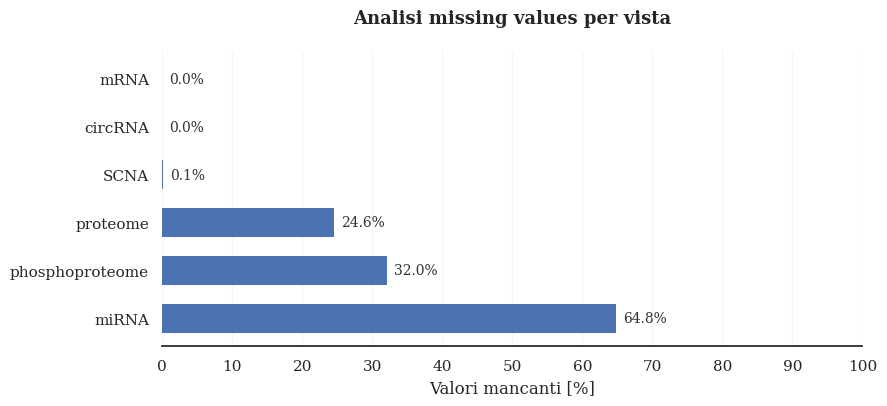


--- Riepilogo Missing Values ---
miRNA               :  64.85%
phosphoproteome     :  32.04%
proteome            :  24.56%
SCNA                :   0.08%
circRNA             :   0.00%
mRNA                :   0.00%


In [ ]:
def plot_missing_percentage_per_view(views):
    # 1. Preparazione Dati
    stats = []
    for name, df in views.items():
        perc = df.isna().mean().mean() * 100
        stats.append({'Vista': name, 'Missing (%)': perc})
    
    df_plot = pd.DataFrame(stats).sort_values('Missing (%)', ascending=False)

    # 2. Setup Estetico
    sns.set_theme(style="white")
    plt.rcParams.update({"font.family": "serif", "font.size": 11})
    
    fig, ax = plt.subplots(figsize=(9, len(views) * 0.7))
    
    # 3. Grafico a barre
    main_color = "#4C72B0"
    bars = ax.barh(df_plot['Vista'], df_plot['Missing (%)'], 
                    color=main_color, edgecolor='none', height=0.6)

    # 4. Annotazioni DINAMICHE
    for bar in bars:
        width = bar.get_width()
        ax.annotate(f'{width:.1f}%', 
                    xy=(width, bar.get_y() + bar.get_height()/2),
                    xytext=(5, 0),             
                    textcoords="offset points", 
                    va='center', ha='left', 
                    fontsize=10, color='#333333')

    # 5. Impostazioni assi e titolo
    ax.set_xlabel("Valori mancanti [%]")
    ax.set_title("Analisi missing values per vista", fontsize=13, fontweight='bold', pad=20)
    
    # Impostiamo il limite X fisso da 0 a 100
    ax.set_xlim(0, 100)
    # Aggiungiamo dei tick ogni 10 o 20 per migliorare la leggibilità sulla scala 0-100
    ax.set_xticks(range(0, 101, 10)) 
    # ---------------------------
    
    # Pulizia assi
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    
    ax.grid(axis='x', linestyle='-', alpha=0.2)
    
    plt.tight_layout()
    plt.show()

    print("\n--- Riepilogo Missing Values ---")
    for _, row in df_plot.iterrows():
        print(f"{row['Vista']:<20}: {row['Missing (%)']:>6.2f}%")

plot_missing_percentage_per_view(aligned_views)

In [12]:
# FILTRAGGIO DELLE FEATURE CON TROPPI MISSING VALUES (SOGLIA 25%)

def filter_views_by_missing(views, threshold=25):
    filtered_views = {}
    names = []
    kept = []
    removed = []

    for name, df in views.items():
        # Calcola percentuale di missing per feature
        missing_per_feature = df.isna().mean() * 100

        # Seleziona feature da mantenere e rimuovere
        features_to_keep = missing_per_feature[missing_per_feature <= threshold].index
        features_to_remove = missing_per_feature[missing_per_feature > threshold].index

        # Crea DataFrame filtrato
        filtered_df = df[features_to_keep].copy()

        # Salva nel dizionario
        filtered_views[name] = filtered_df

        # Salva informazioni di riepilogo
        names.append(name)
        kept.append(len(features_to_keep))
        removed.append(len(features_to_remove))

        print(f"{name}: {df.shape[1]} -> {filtered_df.shape[1]} feature mantenute")

    summary = {
        "view": names,
        "kept_features": kept,
        "removed_features": removed
    }

    return filtered_views, summary


threshold=25
filtered_views, filtered_summary = filter_views_by_missing(aligned_views, threshold)

# Adesso filtered_views contiene tutti i dataset con feature incomplete rimosse

circRNA: 3979 -> 3979 feature mantenute
miRNA: 2416 -> 367 feature mantenute
mRNA: 28057 -> 28057 feature mantenute
phosphoproteome: 8004 -> 4582 feature mantenute
proteome: 11662 -> 7769 feature mantenute
SCNA: 19906 -> 19891 feature mantenute


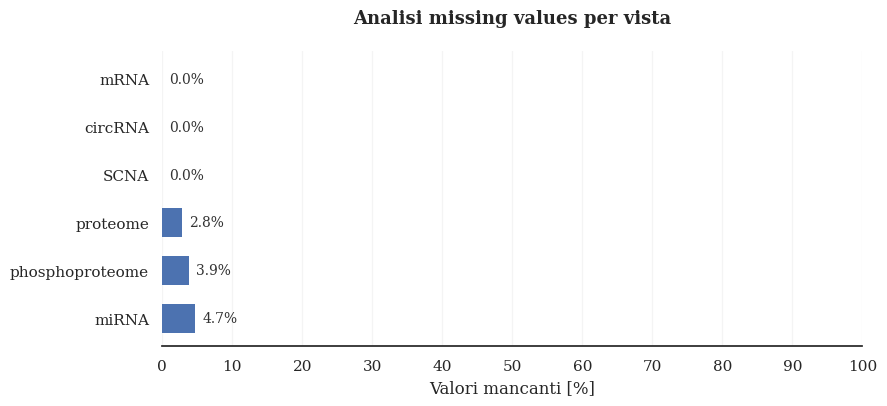


--- Riepilogo Missing Values ---
miRNA               :   4.73%
phosphoproteome     :   3.86%
proteome            :   2.77%
SCNA                :   0.01%
circRNA             :   0.00%
mRNA                :   0.00%


In [13]:
# GRAFICO DELLA PERCENTUALE DI MISSING VALUES PER VISTA DOPO IL FILTRAGGIO

plot_missing_percentage_per_view(filtered_views)

In [14]:
# TABELLA DELLE FEATURE MANTENUTE E RIMOSSE PER VISTA

def display_feature_summary_table(summary):
    # 1. Preparazione DataFrame
    df = pd.DataFrame(summary)
    df['Total'] = df['kept_features'] + df['removed_features']
    df['% Kept'] = (df['kept_features'] / df['Total'] * 100).round(2)
    df['% Removed'] = (df['removed_features'] / df['Total'] * 100).round(2)
    
    df = df.rename(columns={
        'view': 'Vista Omica',
        'kept_features': 'Feature Mantenute',
        'removed_features': 'Feature Rimosse',
        'Total': 'Totale Iniziale'
    })

    df = df.sort_values('Totale Iniziale', ascending=False)

    # 2. Definizione degli stili CSS
    table_styles = [
        # Titoli di colonna: grassetto, allineamento e linea inferiore (Mid Rule)
        {'selector': 'th', 'props': [
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '10px')
        ]},
        # Allineamento celle
        {'selector': 'td', 'props': [
            ('text-align', 'center'),
            ('padding', '8px')
        ]}
    ]

    # 3. Applicazione stile
    styled_df = df.style.format({'% Kept': '{:.1f} %', '% Removed': '{:.1f} %'}) \
                        .set_table_styles(table_styles) \
                        .hide(axis='index') # Nasconde l'indice numerico a sinistra (più pulito)
    
    return styled_df

# Visualizzazione
display(display_feature_summary_table(filtered_summary))

Vista Omica,Feature Mantenute,Feature Rimosse,Totale Iniziale,% Kept,% Removed
mRNA,28057,0,28057,100.0 %,0.0 %
SCNA,19891,15,19906,99.9 %,0.1 %
proteome,7769,3893,11662,66.6 %,33.4 %
phosphoproteome,4582,3422,8004,57.2 %,42.8 %
circRNA,3979,0,3979,100.0 %,0.0 %
miRNA,367,2049,2416,15.2 %,84.8 %


In [15]:
# FILTRAGGIO DELLE FEATURE A VARIANZA ZERO

def analyze_and_filter_zero_variance_features(views):
    filtered_views = {}
    names, kept, removed = [], [], []

    for view_name, df in views.items():
        # Calcolo varianza per feature
        variances = df.var(axis=0)
        non_zero_features = variances[variances > 0].index
        zero_features = variances[variances == 0].index

        # Filtraggio DataFrame
        filtered_df = df[non_zero_features].copy()
        filtered_views[view_name] = filtered_df

        names.append(view_name)
        kept.append(len(non_zero_features))
        removed.append(len(zero_features))

    # 1. Creazione del DataFrame riassuntivo
    summary_df = pd.DataFrame({
        'Vista Omica': names,
        'Feature Mantenute': kept,
        'Feature Rimosse': removed
    })
    
    # 2. Calcoli per la tabella
    summary_df['Totale Iniziale'] = summary_df['Feature Mantenute'] + summary_df['Feature Rimosse']
    summary_df['% Kept'] = (summary_df['Feature Mantenute'] / summary_df['Totale Iniziale'] * 100).round(2)
    
    # Riordino colonne per una lettura logica
    summary_df = summary_df[['Vista Omica', 'Totale Iniziale', 'Feature Mantenute', 'Feature Rimosse', '% Kept']]
    summary_df = summary_df.sort_values('Totale Iniziale', ascending=False)

    # 3. Definizione dello stile professionale (Booktabs style)
    table_styles = [
        {'selector': 'th', 'props': [
            ('font-weight', 'bold'), 
            ('text-align', 'center'), 
            ('padding', '10px'),
        ]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]}
    ]

    # 4. Applicazione stile e visualizzazione
    styled_table = (summary_df.style
                    .format({'% Kept': '{:.1f}%'})
                    .set_table_styles(table_styles)
                    .hide(axis='index'))
    
    print("\n--- Report Filtraggio Varianza Zero ---")
    display(styled_table)

    # Ritorno del dizionario summary originale per compatibilità con il resto del codice
    summary_dict = {
        "view": names,
        "kept_features": kept,
        "removed_features": removed
    }

    return filtered_views, summary_dict

# Chiamata alla funzione
filtered_variance_views, filtered_variance_summary = analyze_and_filter_zero_variance_features(filtered_views)


--- Report Filtraggio Varianza Zero ---


Vista Omica,Totale Iniziale,Feature Mantenute,Feature Rimosse,% Kept
mRNA,28057,25954,2103,92.5%
SCNA,19891,19891,0,100.0%
proteome,7769,7769,0,100.0%
phosphoproteome,4582,4582,0,100.0%
circRNA,3979,3167,812,79.6%
miRNA,367,367,0,100.0%


DATA IMPUTATION (VISTE)

In [16]:
# STANDARDIZZAZIONE DELLE VISTE

def standardize_views(views):
    standardized_views = {}

    for view_name, df in views.items():
        scaler = StandardScaler()
        df_scaled = pd.DataFrame(
            scaler.fit_transform(df),
            columns=df.columns,
            index=df.index
        )
        standardized_views[view_name] = df_scaled
        print(f"Vista '{view_name}' standardizzata: media ~0, std ~1")
    
    return standardized_views

standardized_views = standardize_views(filtered_variance_views)

Vista 'circRNA' standardizzata: media ~0, std ~1
Vista 'miRNA' standardizzata: media ~0, std ~1
Vista 'mRNA' standardizzata: media ~0, std ~1
Vista 'phosphoproteome' standardizzata: media ~0, std ~1
Vista 'proteome' standardizzata: media ~0, std ~1
Vista 'SCNA' standardizzata: media ~0, std ~1


In [17]:
# IMPUTAZIONE KNN DELLE VARIE VISTE

def knn_imputation_multi_view(
    views,
    k_values,
    test_fraction=0.05,
    random_state=42
):

    rng = np.random.default_rng(random_state)

    imputed_views = {}
    summary = {}

    for view_name, df in views.items():
        print(f"\n=== Vista: {view_name} ===")

        df = df.copy()

        # -----------------------------
        # CONTROLLO: nessun valore mancante
        # -----------------------------
        if not df.isna().any().any():
            print("Nessun valore mancante → imputazione non necessaria")

            imputed_views[view_name] = df

            summary[view_name] = {
                "best_k": None,
                "best_rmse": None,  # Nessun RMSE se non c'è imputazione
            }

            continue  # passa alla vista successiva

        # -----------------------------
        # 1. Posizioni osservate
        # -----------------------------
        observed_positions = np.argwhere(~df.isna().values)

        n_test = int(len(observed_positions) * test_fraction)
        print(f"Numero di posizioni di test: {n_test}")
        test_idx = rng.choice(len(observed_positions), size=n_test, replace=False)
        test_positions = observed_positions[test_idx]

        rmse_per_k = {}

        # -----------------------------
        # 2. Selezione del miglior k
        # -----------------------------
        for k in k_values:
            df_masked = df.copy()

            for row, col in test_positions:
                df_masked.iat[row, col] = np.nan

            imputer = KNNImputer(n_neighbors=k)
            df_imputed = pd.DataFrame(
                imputer.fit_transform(df_masked),
                columns=df.columns,
                index=df.index
            )

            y_true = [df.iat[row, col] for row, col in test_positions]
            y_pred = [df_imputed.iat[row, col] for row, col in test_positions]

            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            rmse_per_k[k] = rmse

            print(f"k = {k} → RMSE = {rmse:.4f}")

        best_k = min(rmse_per_k, key=rmse_per_k.get)
        best_rmse = rmse_per_k[best_k]
        print(f"→ Miglior k: {best_k} (RMSE = {best_rmse:.4f})")

        # -----------------------------
        # 3. Imputazione finale
        # -----------------------------
        final_imputer = KNNImputer(n_neighbors=best_k)
        df_imputed_final = pd.DataFrame(
            final_imputer.fit_transform(df),
            columns=df.columns,
            index=df.index
        )

        imputed_views[view_name] = df_imputed_final

        summary[view_name] = {
            "best_k": best_k,
            "best_rmse": best_rmse,  # Solo l'RMSE del k migliore
        }

    return imputed_views, summary

k_values = list(range(3, 20, 2))

imputed_views, imputed_summary = knn_imputation_multi_view(
    standardized_views,
    k_values,
)

print("Imputazione completata.")



=== Vista: circRNA ===
Nessun valore mancante → imputazione non necessaria

=== Vista: miRNA ===
Numero di posizioni di test: 2395
k = 3 → RMSE = 0.6555
k = 5 → RMSE = 0.6453
k = 7 → RMSE = 0.6319
k = 9 → RMSE = 0.6281
k = 11 → RMSE = 0.6294
k = 13 → RMSE = 0.6286
k = 15 → RMSE = 0.6304
k = 17 → RMSE = 0.6321
k = 19 → RMSE = 0.6357
→ Miglior k: 9 (RMSE = 0.6281)

=== Vista: mRNA ===
Nessun valore mancante → imputazione non necessaria

=== Vista: phosphoproteome ===
Numero di posizioni di test: 30174
k = 3 → RMSE = 0.9071
k = 5 → RMSE = 0.8859
k = 7 → RMSE = 0.8805
k = 9 → RMSE = 0.8795
k = 11 → RMSE = 0.8791
k = 13 → RMSE = 0.8809
k = 15 → RMSE = 0.8825
k = 17 → RMSE = 0.8842
k = 19 → RMSE = 0.8865
→ Miglior k: 11 (RMSE = 0.8791)

=== Vista: proteome ===
Numero di posizioni di test: 51742
k = 3 → RMSE = 0.9138
k = 5 → RMSE = 0.8944
k = 7 → RMSE = 0.8919
k = 9 → RMSE = 0.8915
k = 11 → RMSE = 0.8922
k = 13 → RMSE = 0.8933
k = 15 → RMSE = 0.8942
k = 17 → RMSE = 0.8964
k = 19 → RMSE = 0.8

In [18]:
# Crea una tabella riassuntiva da 'imputed_summary'

summary_table = []
for view_name, stats in imputed_summary.items():
    row = {
        "Vista": view_name,
        "k migliore": stats.get("best_k", None),
        "RMSE (k migliore)": stats.get("best_rmse", None),
    }
    summary_table.append(row)

# Converti in DataFrame per una visualizzazione tabellare
summary_df = pd.DataFrame(summary_table)

# Stampa la tabella
print("\n=== Riassunto Imputazione per Vista ===")
print(summary_df.to_string(index=False))



=== Riassunto Imputazione per Vista ===
          Vista  k migliore  RMSE (k migliore)
        circRNA         NaN                NaN
          miRNA         9.0           0.628112
           mRNA         NaN                NaN
phosphoproteome        11.0           0.879088
       proteome         9.0           0.891473
           SCNA         3.0           0.929634


In [19]:
# RI-STANDARDIZZAZIONE DELLE VISTE DOPO L'IMPUTAZIONE

standardized_imputed_views = {}
stats = {}

for view_name, df in imputed_views.items():
    # Calcolo statistiche prima della standardizzazione
    mean_before = df.values.mean()
    std_before = df.values.std()

    # Standardizzazione
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df),
        index=df.index,
        columns=df.columns
    )

    # Calcolo statistiche dopo la standardizzazione
    mean_after = df_scaled.values.mean()
    std_after = df_scaled.values.std()

    # Salvataggio risultati
    standardized_imputed_views[view_name] = df_scaled
    stats[view_name] = {
        "mean_before": mean_before,
        "std_before": std_before,
        "mean_after": mean_after,
        "std_after": std_after
    }

# Visualizzazione statistiche
stats_df = pd.DataFrame(stats).T
stats_df

,mean_before,std_before,mean_after,std_after
circRNA,1.162733e-18,1.000000,2.605913e-18,1.0
miRNA,-1.089161e-02,0.993742,-6.359399e-19,1.0
mRNA,-1.276178e-17,1.000000,1.513728e-19,1.0
phosphoproteome,-9.019919e-04,0.983689,-8.489377e-21,1.0
proteome,-8.484292e-04,0.987866,2.253089e-19,1.0
SCNA,3.531001e-06,0.999977,9.777871e-22,1.0


DATA IMPUTATION (CLINICAL DATA)

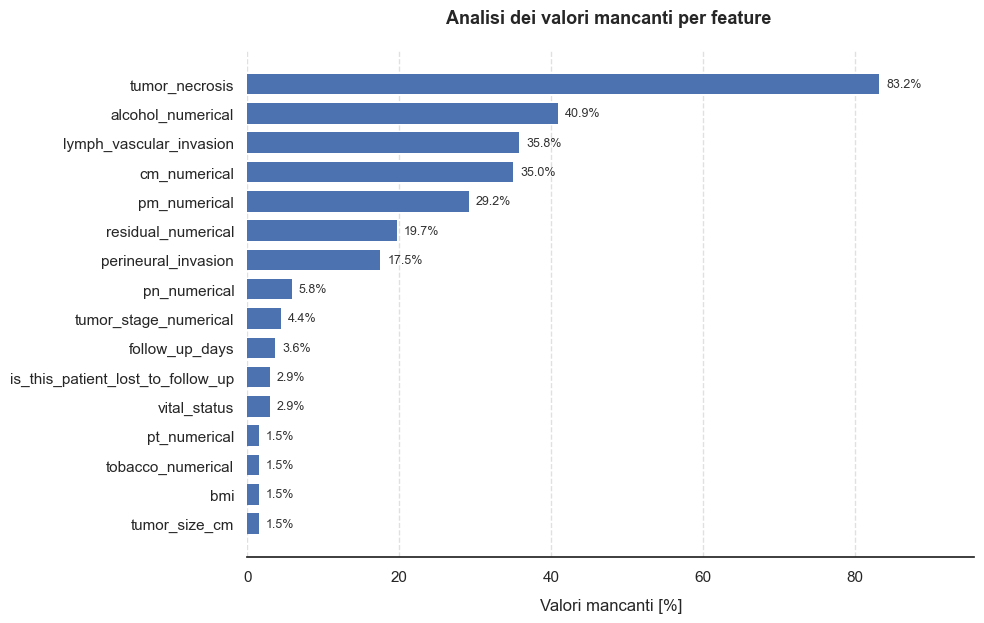

In [20]:
# GRAFICO PER VISUALIZZARE LA PERCENTUALE DI VALORI MANCANTI PER FEATURE (CLINICAL_DATA) PRIMA DEL FILTRAGGIO

def plot_missing_values(df, title_suffix=""):
    # 1. Calcolo e filtraggio (solo feature con missing > 0)
    missing_percent = df.isna().mean() * 100 # percentuale di missing values per ogni feature
    missing_data = missing_percent[missing_percent > 0].sort_values(ascending=True) # mantiene solo le feature con almeno un missing value

    if missing_data.empty:
        print("Nessun valore mancante trovato nel dataset.")
        return

    # 2. Setup estetico scientifico
    sns.set_theme(style="white")
    
    # Altezza dinamica in base al numero di feature
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_data) * 0.4)))

    # 3. Grafico a barre orizzontali (Tinta unita professionale)
    main_color = "#4C72B0"
    bars = ax.barh(missing_data.index, missing_data.values, 
                    color=main_color, edgecolor='none', height=0.7)

    # 4. Annotazioni Dinamiche con offset costante (5 punti)
    for bar in bars:
        width = bar.get_width()
        ax.annotate(f'{width:.1f}%', 
                    xy=(width, bar.get_y() + bar.get_height()/2),
                    xytext=(5, 0),             # Distanza fissa in punti
                    textcoords="offset points",
                    va='center', ha='left', 
                    fontsize=9, fontweight='regular', color='#333333')

    # 5. Raffinatezze assi e titoli
    ax.set_xlabel("Valori mancanti [%]", fontweight='regular', labelpad=10)
    ax.set_title(f"Analisi dei valori mancanti per feature {title_suffix}", 
                 fontsize=13, fontweight='bold', pad=20, loc='center')
    
    # Pulizia Bordi
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    
    # Griglia leggera solo verticale
    ax.xaxis.grid(True, linestyle='--', alpha=0.6)
    ax.yaxis.grid(False)

    # Limite X dinamico per ospitare le etichette
    ax.set_xlim(0, missing_data.max() * 1.15)

    plt.tight_layout()
    plt.show()

plot_missing_values(numerical_clinical_df)

In [21]:
# RIMOZIONE FEATURE CON TROPPI MISSING VALUES (SOGLIA 40%)

def remove_high_missing_features(df, threshold=40):

    # Calcola percentuale di missing per feature
    missing_per_feature = df.isna().mean() * 100

    # Seleziona feature da mantenere e rimuovere
    features_to_keep = missing_per_feature[missing_per_feature <= threshold].index
    features_to_remove = missing_per_feature[missing_per_feature > threshold].index

    # Crea DataFrame filtrato
    filtered_df = df[features_to_keep].copy()


    # Salva informazioni di riepilogo
    kept=len(features_to_keep)
    removed=len(features_to_remove)

    print(f"{df.shape[1]} -> {filtered_df.shape[1]} feature mantenute")
        

    return filtered_df, kept, removed


threshold=40
filtered_numerical_clinical_df, kept, removed = remove_high_missing_features(numerical_clinical_df, threshold)

67 -> 65 feature mantenute


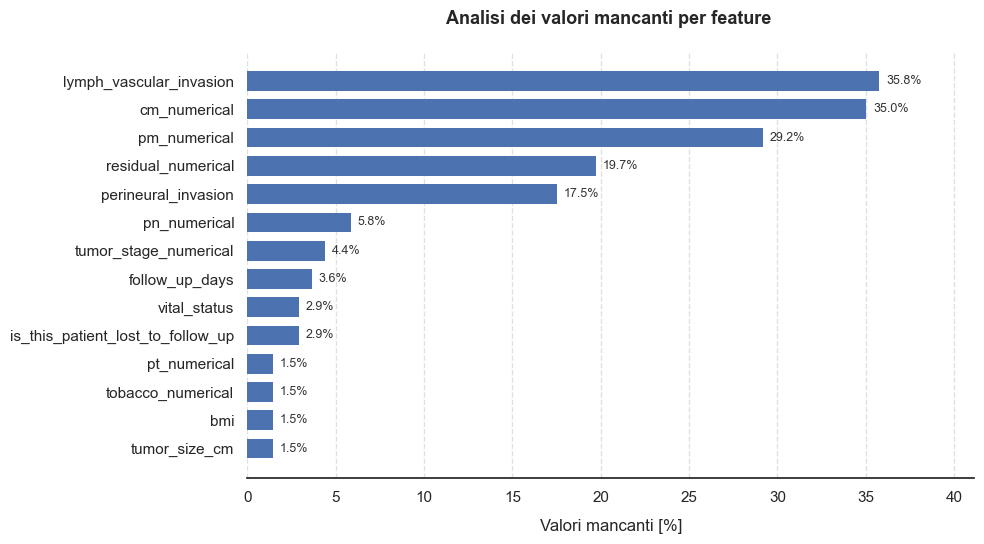

In [22]:
# GRAFICO PER VISUALIZZARE LA PERCENTUALE DI VALORI MANCANTI PER FEATURE (CLINICAL_DATA) DOPO FILTRAGGIO

plot_missing_values(filtered_numerical_clinical_df)

In [23]:
# STANDARDIZZAZIONE DELLE FEATURE CLINICHE

def standardize_non_binary(df):
    # Copia del DataFrame per non modificare l'originale
    df_scaled = df.copy()
    
    # Identifica le colonne binarie (solo 0 e 1)
    binary_cols = [col for col in df.columns
                   if set(df[col].dropna().unique()).issubset({0, 1})]
    
    # Colonne da standardizzare
    cols_to_scale = [col for col in df.columns if col not in binary_cols]
    
    scaler = StandardScaler()
    df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    
    return df_scaled, scaler, cols_to_scale

standardized_numerical_clinical_df, clinical_scaler, cols_to_inverse = standardize_non_binary(filtered_numerical_clinical_df)

In [24]:
#IMPUTAZIONE di CLINICAL DATA

def knn_imputation(
    df,
    k_values,
    test_fraction=0.05,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    imputed_df = None
    summary = {}

    print(f"\n=== Inizio imputazione sul DataFrame ===")

    # -----------------------------
    # CONTROLLO: nessun valore mancante
    # -----------------------------
    if not df.isna().any().any():
        print("Nessun valore mancante → imputazione non necessaria")

        imputed_df = df.copy()

        summary = {
            "best_k": None,
            "best_rmse": None,  # Nessun RMSE se non c'è imputazione
        }

        return imputed_df, summary

    # -----------------------------
    # 1. Posizioni osservate
    # -----------------------------
    observed_positions = np.argwhere(~df.isna().values)

    n_test = int(len(observed_positions) * test_fraction)
    print(f"Numero di posizioni di test: {n_test}")
    test_idx = rng.choice(len(observed_positions), size=n_test, replace=False)
    test_positions = observed_positions[test_idx]

    rmse_per_k = {}

    # -----------------------------
    # 2. Selezione del miglior k
    # -----------------------------
    for k in k_values:
        df_masked = df.copy()

        for row, col in test_positions:
            df_masked.iat[row, col] = np.nan

        imputer = KNNImputer(n_neighbors=k)
        df_imputed = pd.DataFrame(
            imputer.fit_transform(df_masked),
            columns=df.columns,
            index=df.index
        )
        # Calcola l'RMSE per il miglior k
        y_true = [df.iat[row, col] for row, col in test_positions]
        y_pred = [df_imputed.iat[row, col] for row, col in test_positions]

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        rmse_per_k[k] = rmse

        print(f"k = {k} → RMSE = {rmse:.4f}")

    best_k = min(rmse_per_k, key=rmse_per_k.get)
    best_rmse = rmse_per_k[best_k]
    print(f"→ Miglior k: {best_k} (RMSE = {best_rmse:.4f})")

    # -----------------------------
    # 3. Imputazione finale
    # -----------------------------
    final_imputer = KNNImputer(n_neighbors=best_k)
    df_imputed_final = pd.DataFrame(
        final_imputer.fit_transform(df),
        columns=df.columns,
        index=df.index
    )

    imputed_df = df_imputed_final

    summary = {
        "best_k": best_k,
        "best_rmse": best_rmse,  # Solo l'RMSE del k migliore
    }

    return imputed_df, summary

k_values = list(range(3, 20, 2))

imputed_numerical_clinical_df, imputed_numerical_summary = knn_imputation(
    standardized_numerical_clinical_df,
    k_values,
)

print("Imputazione completata.")


=== Inizio imputazione sul DataFrame ===
Numero di posizioni di test: 434
k = 3 → RMSE = 0.4643
k = 5 → RMSE = 0.4348
k = 7 → RMSE = 0.4348
k = 9 → RMSE = 0.4364
k = 11 → RMSE = 0.4260
k = 13 → RMSE = 0.4253
k = 15 → RMSE = 0.4272
k = 17 → RMSE = 0.4224
k = 19 → RMSE = 0.4165
→ Miglior k: 19 (RMSE = 0.4165)
Imputazione completata.


In [25]:
# Calcola la percentuale di missing values per ogni feature
missing_percent = imputed_numerical_clinical_df.isna().mean() * 100

# Stampa il risultato
print("Feature con più del 40% di missing values:")
print(missing_percent[missing_percent > 40])

Feature con più del 40% di missing values:
Series([], dtype: float64)


In [26]:
# VISUALIZZAZIONE DEI CONTEGGI DEI VALORI DOPO L'IMPUTAZIONE
for col in imputed_numerical_clinical_df.columns:
    print(f"\n=== value_counts per la colonna '{col}': ===")
    print(imputed_numerical_clinical_df[col].value_counts(dropna=False))


=== value_counts per la colonna 'age': ===
age
 0.437586    11
-0.102498    10
-0.012484     8
 0.617613     7
-0.192511     7
-0.372539     6
 1.427738     6
 0.347572     5
 1.247711     5
 0.167544     4
-1.992789     4
 0.887655     4
 0.077530     4
-0.912622     4
 0.257558     3
 0.797641     3
-0.462553     3
-0.282525     3
 0.527600     3
 1.157697     3
 0.707627     2
 0.977669     2
-0.552567     2
 1.067683     2
-0.822609     2
-0.732595     2
-1.272678     2
-1.902775     2
 1.787794     2
-2.712900     1
-1.092650     1
-2.352845     1
 1.337725     1
-2.532872     1
 1.517752     1
 1.877808     1
-1.722747     1
-1.002636     1
-2.082803     1
-1.632733     1
-1.182664     1
-0.642581     1
-2.982942     1
-1.812761     1
-1.362692     1
Name: count, dtype: int64

=== value_counts per la colonna 'sex': ===
sex
0.0    71
1.0    66
Name: count, dtype: int64

=== value_counts per la colonna 'tumor_size_cm': ===
tumor_size_cm
-0.099148    17
-0.517427    16
-0.935707   

In [27]:
def inverse_scale_and_round(df_scaled, scaler, cols_to_inverse):
    df_inversed = df_scaled.copy()

    columns_to_round = one_hot_cols + bin_cols + new_ordinal_cols + ["age","follow_up_days"]
    
    df_inversed[cols_to_inverse] = scaler.inverse_transform(df_scaled[cols_to_inverse])
    
    for col in columns_to_round:
        if col in df_inversed.columns:
            df_inversed[col] = df_inversed[col].round()  # Arrotondamento standard
    
    return df_inversed

final_numerical_clinical_df=inverse_scale_and_round(imputed_numerical_clinical_df,clinical_scaler, cols_to_inverse)

In [28]:
# VISUALIZZAZIONE DEI CONTEGGI DEI VALORI DOPO LO SCALING INVERSO

for col in final_numerical_clinical_df.columns:
    print(f"\n=== value_counts per la colonna '{col}': ===")
    print(final_numerical_clinical_df[col].value_counts(dropna=False))


=== value_counts per la colonna 'age': ===
age
69.0    11
63.0    10
64.0     8
71.0     7
62.0     7
60.0     6
80.0     6
68.0     5
78.0     5
66.0     4
42.0     4
74.0     4
65.0     4
54.0     4
67.0     3
73.0     3
59.0     3
61.0     3
70.0     3
77.0     3
72.0     2
75.0     2
58.0     2
76.0     2
55.0     2
56.0     2
50.0     2
43.0     2
84.0     2
34.0     1
52.0     1
38.0     1
79.0     1
36.0     1
81.0     1
85.0     1
45.0     1
53.0     1
41.0     1
46.0     1
51.0     1
57.0     1
31.0     1
44.0     1
49.0     1
Name: count, dtype: int64

=== value_counts per la colonna 'sex': ===
sex
0.0    71
1.0    66
Name: count, dtype: int64

=== value_counts per la colonna 'tumor_size_cm': ===
tumor_size_cm
3.500000    17
3.000000    16
2.500000    15
4.500000    14
4.000000    14
5.000000     7
2.000000     6
2.800000     5
2.700000     3
7.000000     3
6.000000     3
3.200000     3
3.600000     2
6.500000     2
5.500000     2
2.200000     2
4.100000     2
2.900000     2

DATA SAVING

In [29]:
os.makedirs("PDAC_DATA_PREPROCESSED", exist_ok=True)

# Salva ogni DataFrame in un file CSV all'interno della directory
for nome, df in standardized_imputed_views.items():
    df.to_csv(f"PDAC_DATA_PREPROCESSED/{nome}.csv", index=True)

# Salva anche clinical_df
clinical_df.to_csv("PDAC_DATA_PREPROCESSED/clinical.csv", index=True)

final_numerical_clinical_df.to_csv("PDAC_DATA_PREPROCESSED/numerical_clinical.csv", index=True)
